# **Optimizing AUROC loss on imbalanced dataset (PESG)**

**Author**: Zhuoning Yuan,  Gang Li,  Tianbao Yang \
**Version**: 1.4.0

**Introduction**

In this tutorial, you will learn how to quickly train a ResNet20 model by optimizing AUROC using our novel `AUCMLoss` and `PESG` optimizer [[Ref]](https://arxiv.org/abs/2012.03173) on a binary image classification task on Cifar10. After completion of this tutorial, you should be able to use LibAUC to train your own models on your own datasets.

**Reference**:  

If you find this tutorial helpful in your work, please cite our [library paper](https://arxiv.org/abs/2306.03065) and the following papers:

<pre>
@inproceedings{yuan2021large,
  title={Large-scale robust deep auc maximization: A new surrogate loss and empirical studies on medical image classification},
  author={Yuan, Zhuoning and Yan, Yan and Sonka, Milan and Yang, Tianbao},
  booktitle={Proceedings of the IEEE/CVF International Conference on Computer Vision},
  pages={3040--3049},
  year={2021}
}
</pre>

# **Installing LibAUC**
Let’s start with installing our library here. In this tutorial, we will use the lastest version for LibAUC by using ``pip install -U``.

In [ ]:
!pip install -U libauc

# **Importing LibAUC**


In [1]:
from libauc.losses import AUCMLoss
from libauc.optimizers import PESG
from libauc.models import resnet20 as ResNet20
from libauc.datasets import CIFAR10
from libauc.utils import ImbalancedDataGenerator
from libauc.sampler import DualSampler
from libauc.metrics import auc_roc_score

import torch
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from sklearn.metrics import roc_auc_score

## **Reproducibility**

These functions limit the number of sources of randomness behaviors, such as model intialization, data shuffling, etcs. However, completely reproducible results are not guaranteed across PyTorch releases [[Ref]](https://pytorch.org/docs/stable/notes/randomness.html#:~:text=Completely%20reproducible%20results%20are%20not,even%20when%20using%20identical%20seeds.).

In [2]:
def set_all_seeds(SEED):
    # REPRODUCIBILITY
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## **Image Dataset**


Now we define the data input pipeline such as data augmentations. In this tutorial, we use `RandomCrop`, `RandomHorizontalFlip`.




In [3]:
class ImageDataset(Dataset):
    def __init__(self, images, targets, image_size=32, crop_size=30, mode='train'):
       self.images = images.astype(np.uint8)
       self.targets = targets
       self.mode = mode
       self.transform_train = transforms.Compose([
                              transforms.ToTensor(),
                              transforms.RandomCrop((crop_size, crop_size), padding=None),
                              transforms.RandomHorizontalFlip(),
                              transforms.Resize((image_size, image_size), antialias=True),
                              ])
       self.transform_test = transforms.Compose([
                             transforms.ToTensor(),
                             transforms.Resize((image_size, image_size), antialias=True),
                              ])
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        target = self.targets[idx]
        image = Image.fromarray(image.astype('uint8'))
        if self.mode == 'train':
            image = self.transform_train(image)
        else:
            image = self.transform_test(image)
        return image, target

# **Paramaters**

In [4]:
# HyperParameters
SEED = 123
BATCH_SIZE = 128
imratio = 0.1 # for demo
total_epochs = 100
decay_epochs = [50, 75]

lr = 0.1
margin = 1.0
epoch_decay = 0.003 # refers gamma in the paper
weight_decay = 0.0001



# **Loading datasets**

In [5]:
# load data as numpy arrays
train_data, train_targets = CIFAR10(root='./data', train=True).as_array()
test_data, test_targets  = CIFAR10(root='./data', train=False).as_array()

# generate imbalanced data
generator = ImbalancedDataGenerator(verbose=True, random_seed=0)
(train_images, train_labels) = generator.transform(train_data, train_targets, imratio=imratio)
(test_images, test_labels) = generator.transform(test_data, test_targets, imratio=0.5)

# data augmentations
trainSet = ImageDataset(train_images, train_labels)
trainSet_eval = ImageDataset(train_images, train_labels, mode='test')
testSet = ImageDataset(test_images, test_labels, mode='test')

Files already downloaded and verified
Files already downloaded and verified
#SAMPLES: 27777, CLASS 1.0 COUNT: 2777, CLASS RATIO: 0.1000
#SAMPLES: 27777, CLASS 0.0 COUNT: 25000, CLASS RATIO: 0.9000
#SAMPLES: 10000, CLASS 1.0 COUNT: 5000, CLASS RATIO: 0.5000
#SAMPLES: 10000, CLASS 0.0 COUNT: 5000, CLASS RATIO: 0.5000


# **Pretraining (Recommended)**

Following the original [paper](https://arxiv.org/abs/2012.03173), it's recommended to start from a pretrained checkpoint with cross-entropy loss to significantly boost models' performance. It includes a pre-training step with standard cross-entropy loss, and an AUROC maximization step that maximizes an AUROC surrogate loss of the pre-trained model.

In [6]:
from torch.optim import Adam
import warnings
warnings.filterwarnings('ignore')

load_pretrain = True
model = ResNet20(pretrained=False, last_activation=None, num_classes=1)
model = model.cuda()

loss_fn = torch.nn.BCELoss()
optimizer =Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)

trainloader = torch.utils.data.DataLoader(trainSet, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testSet, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


best_test = 0
for epoch in range(total_epochs):
    if epoch in decay_epochs:
        for param_group in optimizer.param_groups:
            param_group['lr'] = 0.1 * param_group['lr']

    model.train()
    for idx, (data, targets) in enumerate(trainloader):
        data, targets  = data.cuda(), targets.cuda()
        y_pred = model(data)
        y_prob = torch.sigmoid(y_pred)
        loss = loss_fn(y_prob, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    ######***evaluation***####
    # evaluation on test sets
    model.eval()
    test_pred_list, test_true_list = [], []
    with torch.no_grad():
        for j, data in enumerate(testloader):
            test_data, test_targets = data
            test_data = test_data.cuda()
            y_pred = model(test_data)
            y_prob = torch.sigmoid(y_pred)
            test_pred_list.append(y_prob.cpu().detach().numpy())
            test_true_list.append(test_targets.numpy())
        test_true = np.concatenate(test_true_list)
    test_pred = np.concatenate(test_pred_list)

    test_auc = auc_roc_score(test_true, test_pred)
    if best_test < test_auc:
        best_test = test_auc
        torch.save(model.state_dict(), 'ce_pretrained_model.pth')

    model.train()
    print("epoch: %s, test_auc: %.4f, best_test_auc: %.4f, lr: %.4f"%(epoch, test_auc, best_test, optimizer.param_groups[0]['lr'] ))

epoch: 0, test_auc: 0.6803, best_test_auc: 0.6803, lr: 0.0010
epoch: 1, test_auc: 0.6997, best_test_auc: 0.6997, lr: 0.0010
epoch: 2, test_auc: 0.7218, best_test_auc: 0.7218, lr: 0.0010
epoch: 3, test_auc: 0.7204, best_test_auc: 0.7218, lr: 0.0010
epoch: 4, test_auc: 0.7074, best_test_auc: 0.7218, lr: 0.0010
epoch: 5, test_auc: 0.7808, best_test_auc: 0.7808, lr: 0.0010
epoch: 6, test_auc: 0.8012, best_test_auc: 0.8012, lr: 0.0010
epoch: 7, test_auc: 0.8222, best_test_auc: 0.8222, lr: 0.0010
epoch: 8, test_auc: 0.8300, best_test_auc: 0.8300, lr: 0.0010
epoch: 9, test_auc: 0.7981, best_test_auc: 0.8300, lr: 0.0010
epoch: 10, test_auc: 0.8193, best_test_auc: 0.8300, lr: 0.0010
epoch: 11, test_auc: 0.8430, best_test_auc: 0.8430, lr: 0.0010
epoch: 12, test_auc: 0.8397, best_test_auc: 0.8430, lr: 0.0010
epoch: 13, test_auc: 0.8459, best_test_auc: 0.8459, lr: 0.0010
epoch: 14, test_auc: 0.8370, best_test_auc: 0.8459, lr: 0.0010
epoch: 15, test_auc: 0.8327, best_test_auc: 0.8459, lr: 0.0010
ep

# **Optimizing AUC Loss**

In [7]:
# oversampling minority class, you can tune it in (0, 0.5]
# e.g., sampling_rate=0.2 is that num of positive samples in mini-batch is sampling_rate*batch_size=13
sampling_rate = 0.2

# dataloaders
sampler = DualSampler(trainSet, BATCH_SIZE, sampling_rate=sampling_rate)
trainloader = torch.utils.data.DataLoader(trainSet, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
trainloader_eval = torch.utils.data.DataLoader(trainSet_eval, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(testSet, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# **Creating models & AUC Optimizer**

In [8]:
# You can include sigmoid/l2 activations on model's outputs before computing loss
model = ResNet20(pretrained=False, last_activation=None, num_classes=1)
model = model.cuda()

# load pretrained model
if load_pretrain:
    PATH = 'ce_pretrained_model.pth'
    state_dict = torch.load(PATH)
    filtered = {k:v for k,v in state_dict.items() if 'linear' not in k}
    msg = model.load_state_dict(filtered, False)
    print(msg)
    model.linear.reset_parameters()
    
# You can also pass Loss.a, Loss.b, Loss.alpha to optimizer (for old version users)
loss_fn = AUCMLoss()
optimizer = PESG(model.parameters(),
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)

_IncompatibleKeys(missing_keys=['linear.weight', 'linear.bias'], unexpected_keys=[])


# **Training**

In [9]:
print ('Start Training')
print ('-'*30)

train_log = []
test_log = []
best_test = 0
for epoch in range(total_epochs):
    if epoch in decay_epochs:
        optimizer.update_regularizer(decay_factor=10) # decrease learning rate by 10x & update regularizer

    train_loss = []
    model.train()
    for data, targets in trainloader:
        data, targets  = data.cuda(), targets.cuda()
        y_pred = model(data)
        y_pred = torch.sigmoid(y_pred)
        loss = loss_fn(y_pred, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())

    # evaluation on train & test sets
    model.eval()
    train_pred_list = []
    train_true_list = []
    with torch.no_grad():
        for train_data, train_targets in trainloader_eval:
            train_data = train_data.cuda()
            train_pred = model(train_data)
            train_pred_list.append(train_pred.cpu().detach().numpy())
            train_true_list.append(train_targets.numpy())
    train_true = np.concatenate(train_true_list)
    train_pred = np.concatenate(train_pred_list)
    train_auc = auc_roc_score(train_true, train_pred)
    train_loss = np.mean(train_loss)

    test_pred_list = []
    test_true_list = []
    with torch.no_grad():
        for test_data, test_targets in testloader:
            test_data = test_data.cuda()
            test_pred = model(test_data)
            test_pred_list.append(test_pred.cpu().detach().numpy())
            test_true_list.append(test_targets.numpy())
    test_true = np.concatenate(test_true_list)
    test_pred = np.concatenate(test_pred_list)
    test_auc =  auc_roc_score(test_true, test_pred)
    if best_test < test_auc:
        best_test = test_auc
    model.train()

    # print results
    print("epoch: %s, train_loss: %.4f, train_auc: %.4f, test_auc: %.4f, best_test_auc: %.4f, lr: %.4f"%(epoch, train_loss, train_auc, test_auc, best_test, optimizer.lr ))
    train_log.append(train_auc)
    test_log.append(test_auc)

Start Training
------------------------------
epoch: 0, train_loss: 0.0267, train_auc: 0.9899, test_auc: 0.9184, best_test_auc: 0.9184, lr: 0.1000
epoch: 1, train_loss: 0.0114, train_auc: 0.9910, test_auc: 0.9169, best_test_auc: 0.9184, lr: 0.1000
epoch: 2, train_loss: 0.0101, train_auc: 0.9897, test_auc: 0.9160, best_test_auc: 0.9184, lr: 0.1000
epoch: 3, train_loss: 0.0099, train_auc: 0.9916, test_auc: 0.9172, best_test_auc: 0.9184, lr: 0.1000
epoch: 4, train_loss: 0.0097, train_auc: 0.9905, test_auc: 0.9153, best_test_auc: 0.9184, lr: 0.1000
epoch: 5, train_loss: 0.0096, train_auc: 0.9888, test_auc: 0.9124, best_test_auc: 0.9184, lr: 0.1000
epoch: 6, train_loss: 0.0095, train_auc: 0.9918, test_auc: 0.9159, best_test_auc: 0.9184, lr: 0.1000
epoch: 7, train_loss: 0.0097, train_auc: 0.9892, test_auc: 0.9109, best_test_auc: 0.9184, lr: 0.1000
epoch: 8, train_loss: 0.0097, train_auc: 0.9906, test_auc: 0.9097, best_test_auc: 0.9184, lr: 0.1000
epoch: 9, train_loss: 0.0093, train_auc: 0.98

epoch: 79, train_loss: 0.0038, train_auc: 0.9942, test_auc: 0.9141, best_test_auc: 0.9263, lr: 0.0010
epoch: 80, train_loss: 0.0039, train_auc: 0.9939, test_auc: 0.9137, best_test_auc: 0.9263, lr: 0.0010
epoch: 81, train_loss: 0.0038, train_auc: 0.9940, test_auc: 0.9137, best_test_auc: 0.9263, lr: 0.0010
epoch: 82, train_loss: 0.0037, train_auc: 0.9944, test_auc: 0.9142, best_test_auc: 0.9263, lr: 0.0010
epoch: 83, train_loss: 0.0036, train_auc: 0.9939, test_auc: 0.9135, best_test_auc: 0.9263, lr: 0.0010
epoch: 84, train_loss: 0.0037, train_auc: 0.9942, test_auc: 0.9140, best_test_auc: 0.9263, lr: 0.0010
epoch: 85, train_loss: 0.0036, train_auc: 0.9944, test_auc: 0.9140, best_test_auc: 0.9263, lr: 0.0010
epoch: 86, train_loss: 0.0035, train_auc: 0.9941, test_auc: 0.9133, best_test_auc: 0.9263, lr: 0.0010
epoch: 87, train_loss: 0.0037, train_auc: 0.9943, test_auc: 0.9133, best_test_auc: 0.9263, lr: 0.0010
epoch: 88, train_loss: 0.0035, train_auc: 0.9944, test_auc: 0.9134, best_test_auc:

# **Visualization**
Now, let's have a look at the learning curves for optimizing AUROC from scratch and from a pretrained model with cross entropy loss.

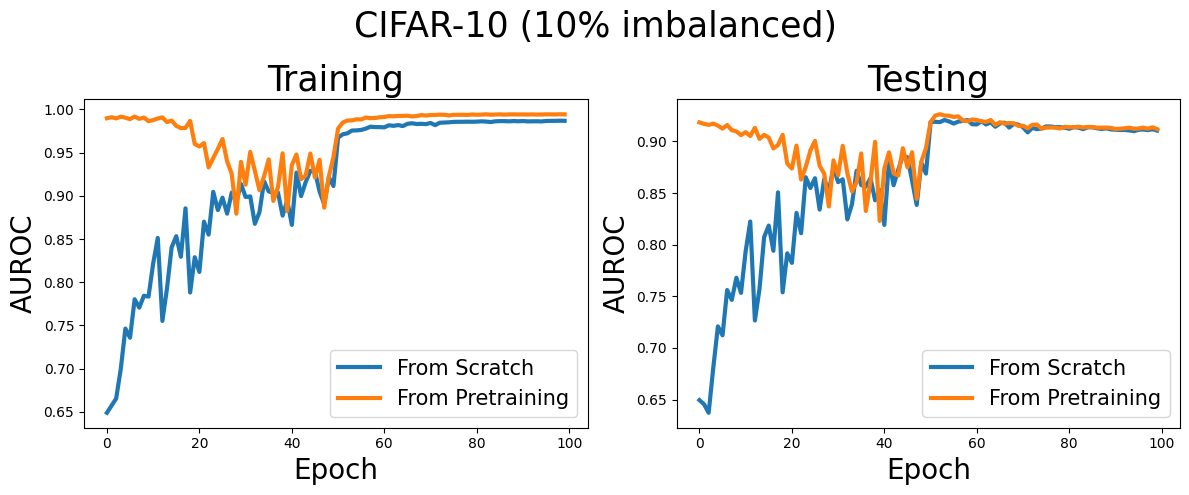

In [13]:
import matplotlib.pyplot as plt
import numpy as np

train_log = [0.9898826935541953, 0.9910432409074541, 0.9897042563917896, 0.9916329996398993, 0.9904884695714801, 0.9888445444724523, 0.9918257111991358, 0.9891807129996399, 0.9906237666546633, 0.9864402592725964, 0.9877531436802305, 0.9895726827511705, 0.9908337846597046, 0.9854517969031328, 0.9871596975153043, 0.9810354483255311, 0.9784206625855238, 0.978685444724523, 0.986740929060137, 0.9600039971191934, 0.9571423406553834, 0.9611580554555276, 0.93296893050054, 0.9437813179690312, 0.9543399063737846, 0.9658336622254232, 0.9399590925459129, 0.9253431544832554, 0.8793414908174289, 0.9393252646741088, 0.9130228519985596, 0.9509074540871444, 0.9290057328051856, 0.9064484479654303, 0.9227444796543033, 0.9421862585523946, 0.8941666114512065, 0.9100127403673028, 0.9492449981994959, 0.882421073100468, 0.9355596543032048, 0.947942434281599, 0.9193655311487217, 0.9236186532229023, 0.9489736550234066, 0.9212254663305725, 0.9417414259992798, 0.8863336046092906, 0.922527115592366, 0.9447027439683111, 0.9778282823190494, 0.9848474900972273, 0.9871959812747569, 0.987348836874325, 0.9886746416996759, 0.988413100468131, 0.9906906445804825, 0.9899555203456967, 0.9901363341735687, 0.9909658912495499, 0.9913169175369104, 0.9923514584083544, 0.9921012603528987, 0.99257928700036, 0.992615945264674, 0.992794375225063, 0.9919594382427079, 0.9924108030248472, 0.9935516168527189, 0.9930049117752971, 0.9935673460568959, 0.99367293482175, 0.9940343104069139, 0.9938503853078863, 0.9931476557436083, 0.9938241123514584, 0.9938535974072743, 0.9938952394670507, 0.9937098883687434, 0.9942139863161685, 0.9939250846236947, 0.9940403024846958, 0.9944042851998559, 0.9939437522506303, 0.9941618149081743, 0.9943501764494058, 0.9940743104069139, 0.9943205905653583, 0.9943760893050054, 0.9942260424918977, 0.994299387828592, 0.9941531148721644, 0.9943211523226504, 0.9941013179690313, 0.9942401296362982, 0.9943596398991718, 0.9943389845156643, 0.9942772200216061, 0.9944786244148361, 0.9943196543032049]
test_log = [0.9183891200000001, 0.9169461199999999, 0.91601316, 0.9172124800000001, 0.9152754799999999, 0.91236998, 0.9158552400000001, 0.9109192400000001, 0.90969144, 0.9060574000000001, 0.9089745599999999, 0.90520976, 0.9130611800000001, 0.9024255800000001, 0.9063105599999999, 0.9036700400000001, 0.89319072, 0.89649804, 0.90637532, 0.87850264, 0.87374726, 0.89593026, 0.86306704, 0.87526192, 0.8911215600000001, 0.9004719800000001, 0.87643676, 0.8687858, 0.83703196, 0.88164982, 0.8670908399999999, 0.8957164200000001, 0.8691409, 0.85157752, 0.86043644, 0.8883379600000001, 0.8326116800000001, 0.8615587199999999, 0.8995787199999999, 0.8230415199999999, 0.8737699200000001, 0.8894368399999999, 0.8691527600000001, 0.8668749200000001, 0.8933767999999999, 0.8749373599999999, 0.8895097000000001, 0.8443739600000001, 0.88039534, 0.8935050200000001, 0.91865376, 0.92494176, 0.92627144, 0.92511312, 0.92476486, 0.9237188399999999, 0.9242554000000001, 0.9200603, 0.91960028, 0.92120886, 0.92074442, 0.9194853199999999, 0.91884316, 0.9207244, 0.91600242, 0.91855174, 0.91728042, 0.9178431, 0.91747388, 0.91504892, 0.9151712399999999, 0.91265792, 0.9160668000000001, 0.91629366, 0.91231272, 0.9133623599999999, 0.9134465999999999, 0.9133754, 0.9125013000000001, 0.9141352199999999, 0.9137363400000001, 0.91369698, 0.9142360399999999, 0.9134938, 0.91397488, 0.91397588, 0.9132614399999999, 0.9132568799999999, 0.9133586600000001, 0.91309332, 0.91198434, 0.9122838, 0.91270148, 0.91329482, 0.9122304, 0.9124734400000001, 0.9133293599999999, 0.91228554, 0.91366188, 0.9118866400000001]
train_log_scratch = [0.6487864241987756, 0.6570376953546992, 0.6652891969751531, 0.6997062441483615, 0.7463313359740728, 0.7357006769895571, 0.7802633201296363, 0.7705517536910335, 0.7843153619013324, 0.7833184587684552, 0.8215275837234426, 0.8512112351458407, 0.7551542239827151, 0.7930894346416998, 0.8403568815268277, 0.8532969679510263, 0.8294249405833631, 0.8855697515304286, 0.78807505221462, 0.8289326179330212, 0.8119374576881526, 0.870111199135758, 0.8550965286280157, 0.9046458768455168, 0.8835233489377026, 0.8978948001440403, 0.879345790421318, 0.9038241699675909, 0.8927085199855959, 0.9137222038170687, 0.8986654807346055, 0.899318314728124, 0.8676161253150882, 0.8810589701116314, 0.9168891897731364, 0.9050961325171047, 0.9034263089665105, 0.9039333381346778, 0.8770988260712999, 0.894781469211379, 0.8663913431760892, 0.9268936694274399, 0.8996783867482894, 0.915994987396471, 0.929009859560677, 0.928035664386028, 0.9050354555275475, 0.8903964061937343, 0.9215445012603527, 0.9113632985235866, 0.9673894418437161, 0.9712597479294202, 0.9723788260712999, 0.9756220813827873, 0.9758165790421317, 0.9763222758372344, 0.9778468347137198, 0.9800894202376665, 0.9796207850198057, 0.9795943680230466, 0.9793308318329131, 0.98173389989197, 0.981050140439323, 0.9819711199135758, 0.9807803312927621, 0.9833618941303564, 0.9840564638098668, 0.9831874540871446, 0.9834106013683832, 0.9830627583723442, 0.9843784155563557, 0.9818939575081023, 0.9846380842635938, 0.9848955851638459, 0.985140907454087, 0.9856526611451206, 0.9857646957148001, 0.985784616492618, 0.9858735181850918, 0.9857995966870723, 0.9859454375225063, 0.9862662873604608, 0.9860312855599568, 0.9854559452646742, 0.9863081166726684, 0.9865275477133597, 0.9865129420237667, 0.9863067050774218, 0.9866201512423478, 0.9863383363341736, 0.986646618653223, 0.9862285487936622, 0.9862882679150162, 0.9863598127475695, 0.9861665394310407, 0.9867232841195536, 0.986805358300324, 0.9868380842635938, 0.9870069139359021, 0.9868661289160965]
test_log_scratch = [0.64954048, 0.6455573, 0.63726404, 0.6808524800000001, 0.72093944, 0.71224636, 0.7561244, 0.7465077000000001, 0.7680155999999999, 0.7533547600000001, 0.7935768799999999, 0.82246204, 0.7266309400000002, 0.75730204, 0.8073705600000001, 0.8185382600000001, 0.7940768, 0.8506930199999998, 0.7538938400000001, 0.7916545600000001, 0.78242764, 0.83077196, 0.81109932, 0.86531856, 0.85488648, 0.8643425200000001, 0.83400484, 0.8635066, 0.85143188, 0.8750814800000001, 0.86054532, 0.86332512, 0.8245006000000001, 0.83921446, 0.87151104, 0.8577713600000001, 0.85627144, 0.86444628, 0.8429737200000001, 0.85292974, 0.81913848, 0.8814284400000001, 0.8575169999999999, 0.87243962, 0.88622472, 0.8845532, 0.8620859999999999, 0.83851166, 0.8795108, 0.86881428, 0.91882244, 0.91899608, 0.9186357199999998, 0.9207326799999999, 0.9193346, 0.9172649600000001, 0.9191856, 0.9198186000000002, 0.9206534800000001, 0.91662526, 0.91642482, 0.9194517199999999, 0.9164139400000001, 0.9184157399999999, 0.9142051, 0.91731436, 0.91813376, 0.9133845600000001, 0.91703996, 0.91620514, 0.9136835799999999, 0.9087101599999999, 0.9130744, 0.9118543, 0.91251262, 0.91449428, 0.9144272400000001, 0.9138009599999999, 0.9138013400000001, 0.91329232, 0.9122549799999999, 0.9137974199999999, 0.9133186, 0.91187654, 0.91368122, 0.9136239, 0.9126864, 0.9120131200000001, 0.91264694, 0.9115934600000001, 0.9113091999999999, 0.91100668, 0.9110379000000001, 0.91061902, 0.9098951200000001, 0.9112703600000001, 0.91152912, 0.9108944800000001, 0.9118080400000002, 0.9104458400000001]


fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12,5))
plt.suptitle('CIFAR-10 (10% imbalanced)',fontsize=25)

x=np.arange(len(train_log))
ax0.plot(x, train_log_scratch,  label='From Scratch', linewidth=3)
ax0.plot(x, train_log,  label='From Pretraining', linewidth=3)
ax0.set_title('Training',fontsize=25)
ax1.plot(x, test_log_scratch, label='From Scratch', linewidth=3)
ax1.plot(x, test_log, label='From Pretraining', linewidth=3)
ax1.set_title('Testing',fontsize=25)

ax0.legend(fontsize=15)
ax1.legend(fontsize=15)
ax0.set_ylabel('AUROC', fontsize=20)
ax0.set_xlabel('Epoch', fontsize=20)
ax1.set_ylabel('AUROC', fontsize=20)
ax1.set_xlabel('Epoch', fontsize=20)

plt.tight_layout()
plt.savefig('auroc_p.png')